Testing HD HMM on our datasets.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from AlazarPowerSweepData import *

Your hmmlearn version doesn't support parallel processing. Using single-core HMM.


In [3]:
%matplotlib inline

In [4]:

power_sweep_obj = AlazarPowerSweepData(r"E:\Quasiparticles\Andreev_Spectroscopy\040425\L1A_trapping_measurement_RUN0\phi_0p450",interactive=True)

Created figure directory: E:\Quasiparticles\Andreev_Spectroscopy\040425\L1A_trapping_measurement_RUN0\phi_0p450\PowerSweepfigures\20250411_145059


In [5]:
power_sweep_obj.get_voltage_records(avgTime=2)

Setting up directories and paths...
Reading and sorting data files...
Reading and updating the metadata...


In [6]:
power_sweep_obj.data[0].shape


(2, 83334)

In [7]:
create_IQ_plot(power_sweep_obj.data[7])

In [8]:
iq_data = power_sweep_obj.data[7]  # shape (2, 83334)
traj = iq_data.T[:, np.newaxis, :]  # now shape: (83334, 1, 2)


# HDPHMM

Package: [https://github.com/bencoscia/hdphmm](https://github.com/bencoscia/hdphmm)

In [ ]:
import hdphmm
from hdphmm import InfiniteHMM

In [ ]:
real_generator = type('', (), {})()  # anonymous empty object
real_generator.traj = traj  # shape: (83334, 1, 2)
real_generator.dim = 2
real_generator.ntraj = 1

# Dummy placeholders to satisfy the model
real_generator.T = None
real_generator.cov = None
real_generator.phis = None
real_generator.mu = None
real_generator.state_sequence = None  # <- crucial fix


# Run inference
ihmm = InfiniteHMM(real_generator, max_states=10, prior='MNIW-N')
ihmm.inference(niter=100)




In [ ]:
%matplotlib inline

In [ ]:
ihmm.summarize_results(traj_no=0)
plt.show()

In [ ]:
ihmm.fix_state_sequence

# pyshmm


In [9]:
data = iq_data.T

In [10]:
data.shape

(83334, 2)

In [11]:
%matplotlib inline

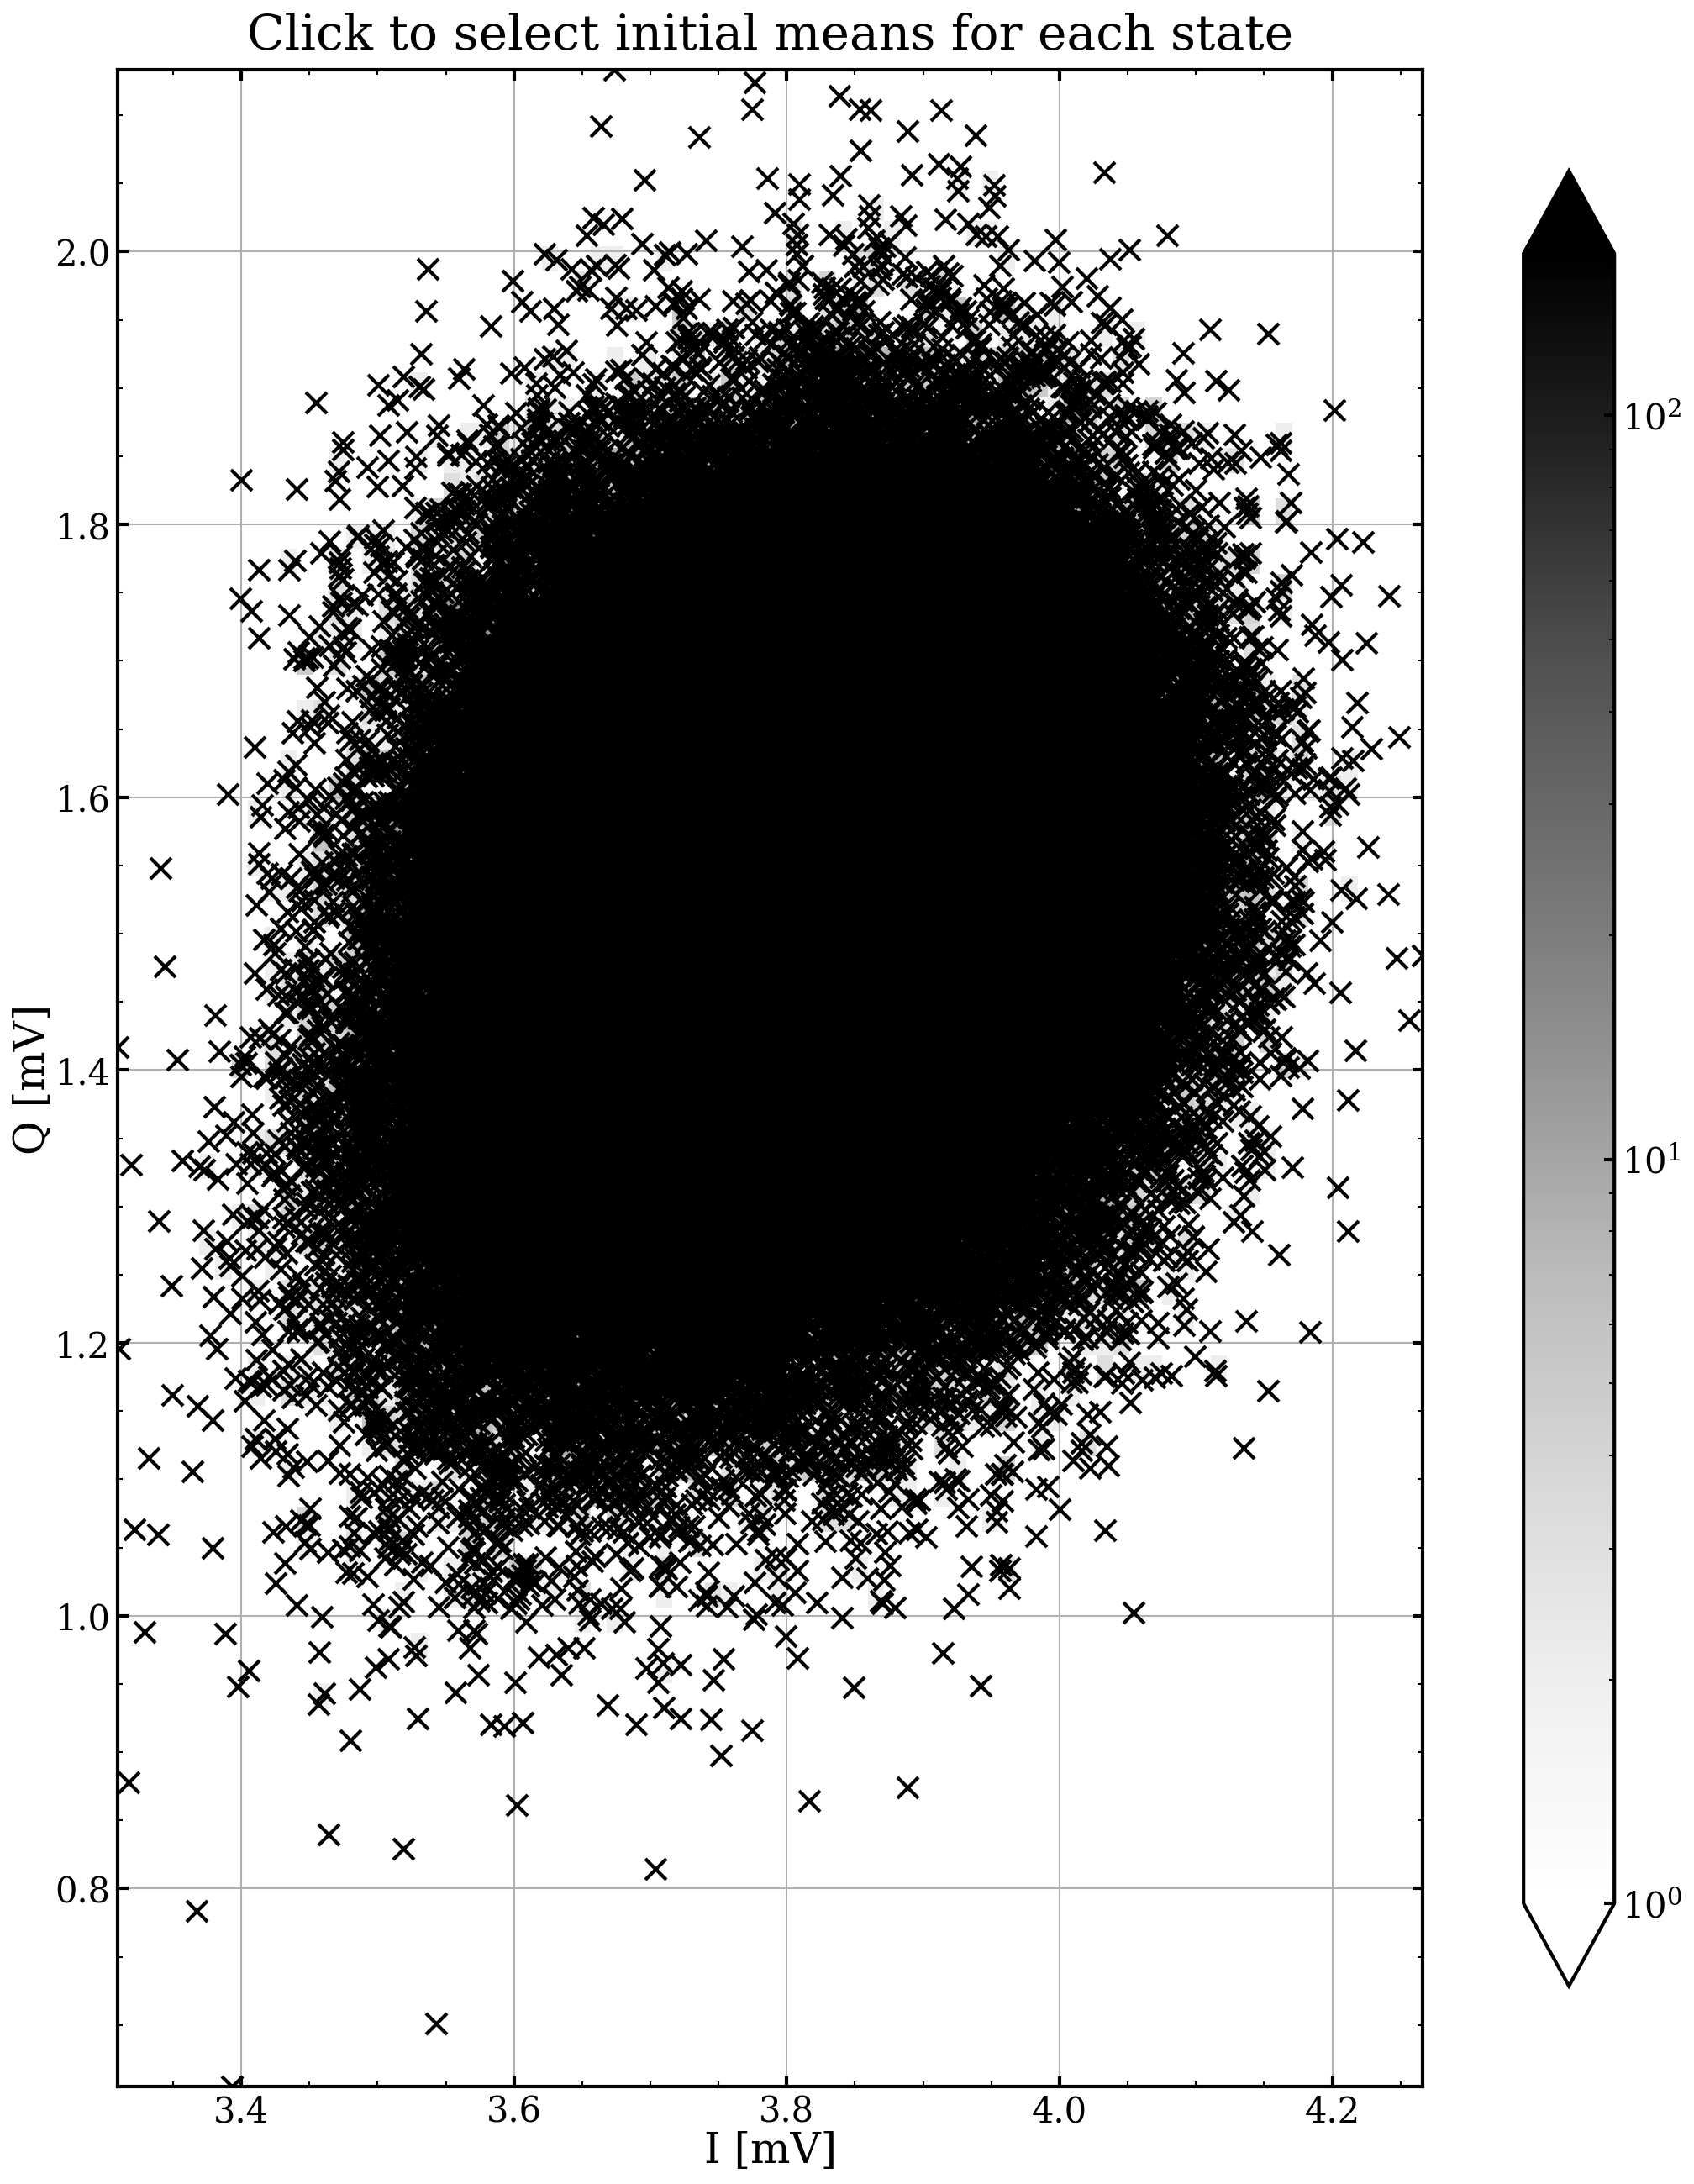

In [12]:
import numpy as np
from matplotlib import pyplot as plt

plt.plot(data[:,0],data[:,1],'kx')
plt.show()

In [13]:
import pyhsmm
import pyhsmm.basic.distributions as distributions

obs_dim = 2
Nmax = 25

obs_hypparams = {'mu_0':np.zeros(obs_dim),
                'sigma_0':np.eye(obs_dim),
                'kappa_0':0.3,
                'nu_0':obs_dim+5}
dur_hypparams = {'alpha_0':2*30,
                 'beta_0':2}

obs_distns = [distributions.Gaussian(**obs_hypparams) for state in range(Nmax)]
dur_distns = [distributions.PoissonDuration(**dur_hypparams) for state in range(Nmax)]

posteriormodel = pyhsmm.models.WeakLimitHDPHSMM(
        alpha=6.,gamma=6., # better to sample over these; see concentration-resampling.py
        init_state_concentration=6., # pretty inconsequential
        obs_distns=obs_distns,
        dur_distns=dur_distns)

c:\users\lfl\lflpython-github\measurementscripts\quasiparticles\hmm_analysis\pyhsmm\pyhsmm\internals\transitions.py:17: UserWarning: using slow transition counting
  warn('using slow transition counting')


In [14]:
posteriormodel.add_data(data,trunc=60)

In [15]:
from pyhsmm.util.text import progprint_xrange
import copy

In [16]:
models = []
for idx in progprint_xrange(150):
    posteriormodel.resample_model()
    if (idx+1) % 10 == 0:
        models.append(copy.deepcopy(posteriormodel))

ModuleNotFoundError: No module named 'pyhsmm.internals.hsmm_messages_interface'

In [ ]:
fig = plt.figure()
for idx, model in enumerate(models):
    plt.clf()
    model.plot()
    plt.gcf().suptitle('HDP-HSMM sampled after %d iterations' % (10*(idx+1)))
    plt.savefig('iter_%.3d.png' % (10*(idx+1)))

In [ ]:
model_samples = [model.resample_and_copy() for itr in progprint_xrange(150)]

In [ ]:
import cPickle
with open('sampled_models.pickle','w') as outfile:
    cPickle.dump(model_samples,outfile,protocol=-1)